# PREDICTING HEART DISEASE RISK

## importing libraries

In [40]:
#for data handling
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt
import seaborn as sns

# Model Building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# building the calculator
import joblib


## Importing Dataset

In [2]:
heart = pd.read_csv('C:/Users/pardm/Downloads/archive/Heart_Disease_Prediction.csv')

In [3]:
heart.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


### mapping target variable

In [4]:
# converting text to lowercase and remove spaces
heart["Heart Disease"] = heart["Heart Disease"].str.strip().str.lower()

# map to numeric values
heart["Heart Disease"] = heart["Heart Disease"].map({
    "absence": 0,
    "presence": 1
})

### renaming the columns

In [6]:
for col in heart.columns:
    print(col)




Age
Sex
Chest pain type
BP
Cholesterol
FBS over 120
EKG results
Max HR
Exercise angina
ST depression
Slope of ST
Number of vessels fluro
Thallium
Heart Disease


In [7]:
heart.columns = [
    "age",
    "sex",
    "chest_pain",
    "bp",
    "cholesterol",
    "fasting_sugar",
    "rest_ecg",
    "max_hr",
    "exercise_angina",
    "st_depression",
    "st_slope",
    "num_major_vessels",
    "thallium",
    "heart_disease"
]

In [8]:
heart.head()

,age,sex,chest_pain,bp,cholesterol,fasting_sugar,rest_ecg,max_hr,exercise_angina,st_depression,st_slope,num_major_vessels,thallium,heart_disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [9]:
heart["heart_disease"].unique()

array([1, 0], dtype=int64)

In [10]:
heart['heart_disease'].value_counts()

heart_disease
0    150
1    120
Name: count, dtype: int64

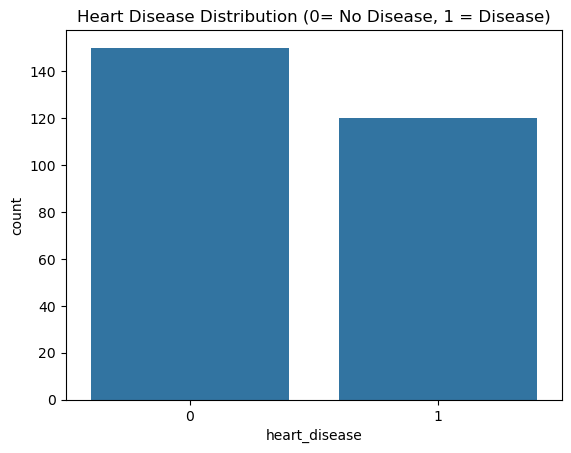

In [11]:
sns.countplot(x="heart_disease", data=heart)
plt.title("Heart Disease Distribution (0= No Disease, 1 = Disease)")
plt.show()

#### Data Overview

In [12]:
heart.shape

(270, 14)

In [13]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                270 non-null    int64  
 1   sex                270 non-null    int64  
 2   chest_pain         270 non-null    int64  
 3   bp                 270 non-null    int64  
 4   cholesterol        270 non-null    int64  
 5   fasting_sugar      270 non-null    int64  
 6   rest_ecg           270 non-null    int64  
 7   max_hr             270 non-null    int64  
 8   exercise_angina    270 non-null    int64  
 9   st_depression      270 non-null    float64
 10  st_slope           270 non-null    int64  
 11  num_major_vessels  270 non-null    int64  
 12  thallium           270 non-null    int64  
 13  heart_disease      270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 29.7 KB


In [15]:
heart.describe()

,age,sex,chest_pain,bp,cholesterol,fasting_sugar,rest_ecg,max_hr,exercise_angina,st_depression,st_slope,num_major_vessels,thallium,heart_disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


In [16]:
heart.isnull().sum()

age                  0
sex                  0
chest_pain           0
bp                   0
cholesterol          0
fasting_sugar        0
rest_ecg             0
max_hr               0
exercise_angina      0
st_depression        0
st_slope             0
num_major_vessels    0
thallium             0
heart_disease        0
dtype: int64

## Age vs Disease


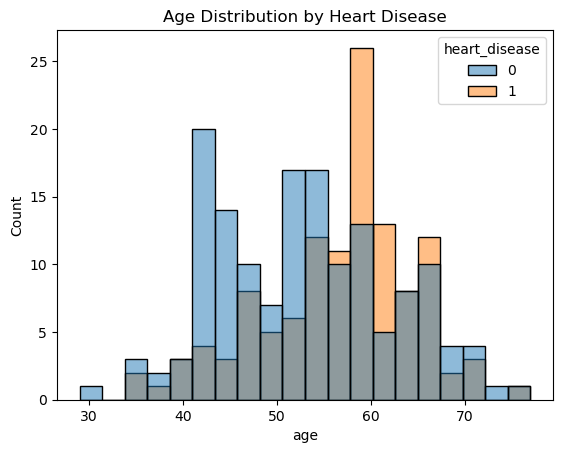

In [17]:
sns.histplot(data=heart, x="age", hue="heart_disease", bins=20)
plt.title("Age Distribution by Heart Disease")
plt.show()

## EDA

### Correlation Heatmap

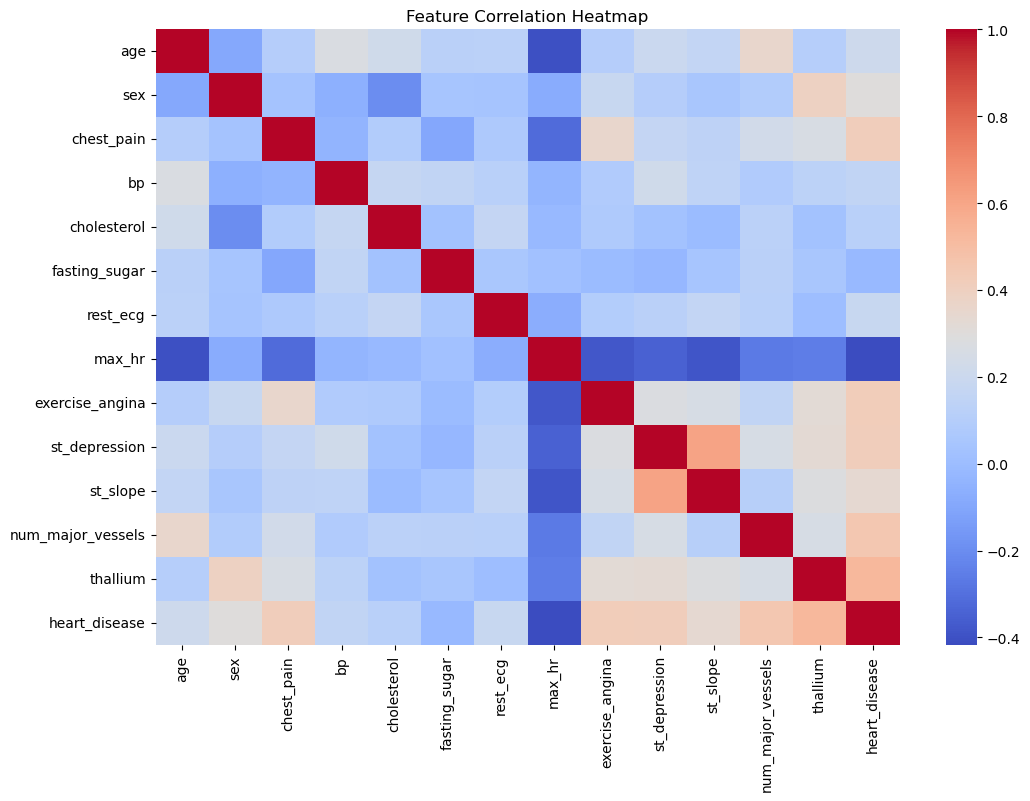

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(heart.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

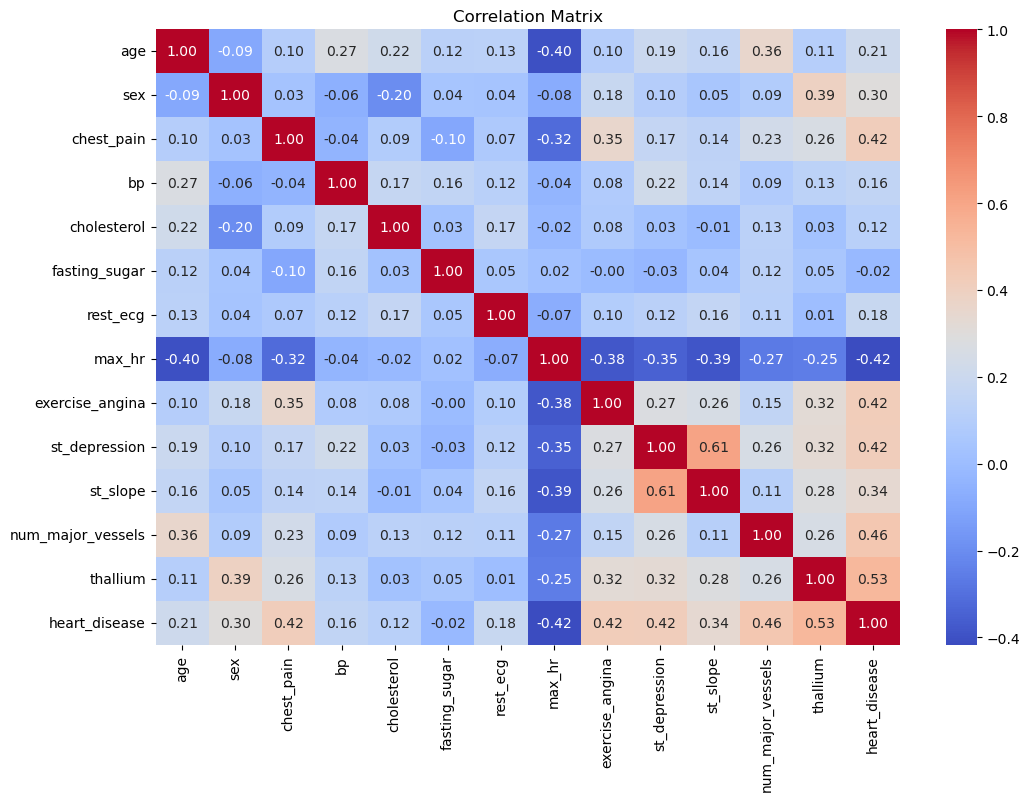

In [19]:
# Compute correlation matrix
corr_matrix = heart.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [20]:
corr_target = heart.corr()["heart_disease"].sort_values(ascending=False)

print(corr_target)

heart_disease        1.000000
thallium             0.525020
num_major_vessels    0.455336
exercise_angina      0.419303
st_depression        0.417967
chest_pain           0.417436
st_slope             0.337616
sex                  0.297721
age                  0.212322
rest_ecg             0.182091
bp                   0.155383
cholesterol          0.118021
fasting_sugar       -0.016319
max_hr              -0.418514
Name: heart_disease, dtype: float64


### Cholecsterol vs Disease

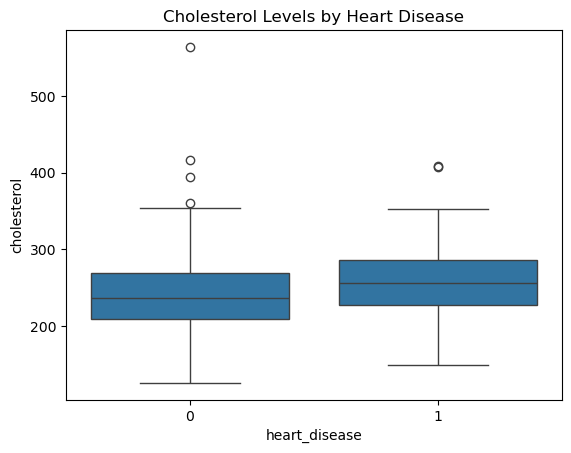

In [21]:
sns.boxplot(x="heart_disease", y="cholesterol", data=heart)
plt.title("Cholesterol Levels by Heart Disease")
plt.show()

In [22]:
### max heart vs disease

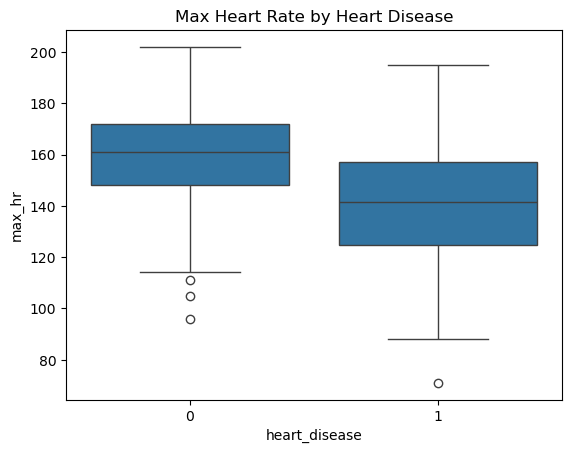

In [23]:
sns.boxplot(x="heart_disease", y="max_hr", data=heart)
plt.title("Max Heart Rate by Heart Disease")
plt.show()

### chest pain vs disease

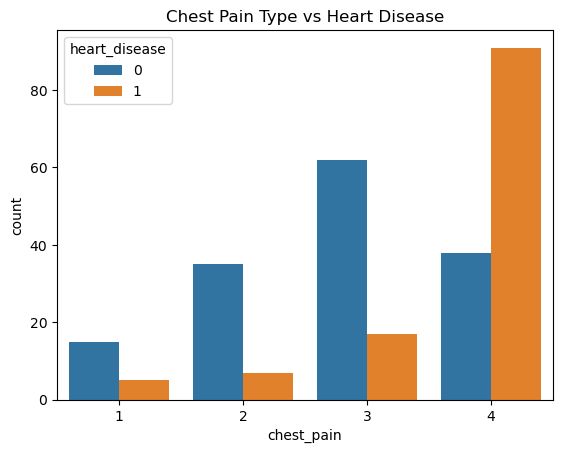

In [25]:
sns.countplot(x="chest_pain", hue="heart_disease", data=heart)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [26]:
# features (inputs)
X = heart.drop("heart_disease", axis=1)

# target (what we predict)
y = heart["heart_disease"]

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
y_pred = model.predict(X_test)

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9074074074074074
[[31  2]
 [ 3 18]]
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



In [32]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[31  2]
 [ 3 18]]


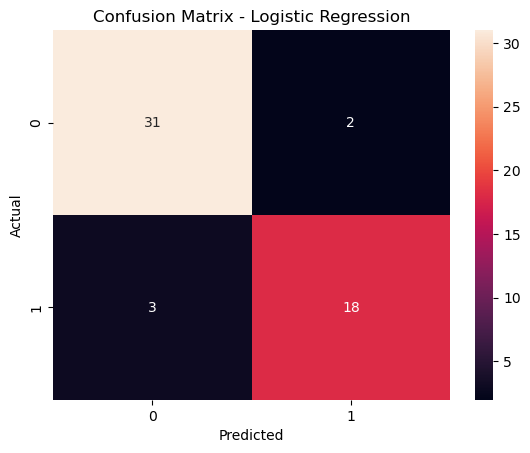

In [33]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

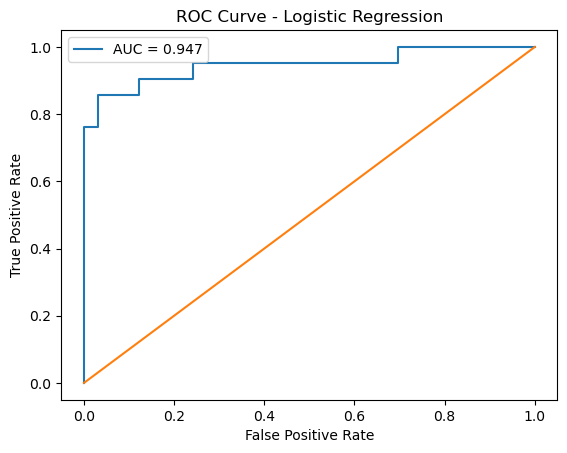

In [34]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="AUC = " + str(round(auc_score, 3)))
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


In [35]:


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7962962962962963


In [36]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

print("Logistic Regression AUC:", auc_score)
print("Random Forest AUC:", rf_auc)


Logistic Regression AUC: 0.9466089466089466
Random Forest AUC: 0.8852813852813852


In [37]:

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)
print(feature_importance)

              Feature  Coefficient
11  num_major_vessels     0.826083
1                 sex     0.642202
2          chest_pain     0.622595
12           thallium     0.568964
9       st_depression     0.503589
3                  bp     0.432772
8     exercise_angina     0.377032
10           st_slope     0.337535
4         cholesterol     0.286264
6            rest_ecg     0.067384
0                 age    -0.082502
7              max_hr    -0.212811
5       fasting_sugar    -0.335791


In [38]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)
print(rf_importance)

              Feature  Importance
9       st_depression    0.138002
2          chest_pain    0.133470
12           thallium    0.114730
7              max_hr    0.105259
0                 age    0.095171
11  num_major_vessels    0.085092
4         cholesterol    0.083485
3                  bp    0.079547
10           st_slope    0.059689
8     exercise_angina    0.052720
1                 sex    0.025117
6            rest_ecg    0.018442
5       fasting_sugar    0.009276


#### working with randoma values to see how the model predicts heart disease

In [39]:
new_patient = [[60,1,4,140,289,0,2,120,1,2.3,2,2,7]]

new_patient_scaled = scaler.transform(new_patient)

prediction = model.predict(new_patient_scaled)

probability = model.predict_proba(new_patient_scaled)

print("Prediction:", prediction)
print("Probability of Heart Disease:", probability)

Prediction: [1]
Probability of Heart Disease: [[0.00922109 0.99077891]]


C:\Users\pardm\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Building an a Heart Risk Calculator
#### this can be used buy the doctors to predict heart risk

In [41]:

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [42]:
joblib.dump(model, "heart_disease_model.pkl")

['heart_disease_model.pkl']